# IT5006 - EDA starter
## SmartCommerce Data Exploration

**Duration:** ~60 minutes  
**Prerequisites:** Lab 1.0 (Python/PyTorch Refresher)  
**Environment:** Google Colab (recommended) or local Jupyter

---

### 🎯 Learning Objectives

This mini lab is for you to:

1. Load and understand the **Olist e-commerce dataset** schema
2. **Merge multiple tables** using relational keys (order_id, customer_id, product_id)
3. Compute foundational **business KPIs** (Revenue, AOV, Repeat Rate, On-Time Delivery)
4. Create basic **visualizations** to understand data distributions
5. Document the data assets available for downstream analytics

---

### 📊 About the Dataset

**Olist** is a Brazilian e-commerce platform. The dataset contains ~100K orders from 2016-2018 across 9 interconnected tables:

| Table | Description | Key Columns |
|-------|-------------|-------------|
| `orders` | Order metadata & timestamps | order_id, customer_id, status, timestamps |
| `order_items` | Line items per order | order_id, product_id, price, freight |
| `customers` | Customer location | customer_id, city, state |
| `products` | Product catalog | product_id, category, dimensions |
| `sellers` | Seller location | seller_id, city, state |
| `payments` | Payment details | order_id, payment_type, value |
| `reviews` | Customer feedback | order_id, score, comment |
| `geolocation` | Zip code coordinates | zip_code, lat, lng |
| `category_translation` | Portuguese → English | category names |

> 💡 **SmartCommerce** is our fictional brand name for this e-commerce case study throughout the course.


---

## 1. Environment Setup & Data Loading


In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
# Install dependencies (uncomment if running in Colab)
# !pip install -q pandas numpy matplotlib seaborn plotly

import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")


pandas: 2.3.2
numpy: 2.3.2


# === DATA PATH CONFIGURATION ===
# Option 1: Google Colab with Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/2026_work/IS5126/Olist"


In [3]:
import os
from pathlib import Path

# Resolve current directory (compatible with both Jupyter .ipynb notebooks and .py scripts)
try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    current_dir = Path.cwd().resolve()

# Scan upwards to find repository root (detecting 'data' folder or '.git' directory)
def find_repo_root(start_path: Path) -> Path:
    for parent in [start_path] + list(start_path.parents):
        if (parent / "data").exists() or (parent / ".git").exists():
            return parent
    return start_path.parent

REPO_ROOT = find_repo_root(current_dir)

# Define relative paths from repository root
DATA_DIR = REPO_ROOT / "data" / "business" / "dashboard"
OUTPUT_DIR = REPO_ROOT / "data" / "business" / "dashboard"
OUTPUT_FILE = OUTPUT_DIR / "smartcommerce_consolidated.csv"
OUTPUT_FEATURE_LIST = OUTPUT_DIR / "olist_features_list.xlsx.csv"


# Ensure target directories exist before writing
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify path resolution
if DATA_DIR.exists():
    print(f"✅ Data directory found: {DATA_DIR}")
    print(f"   Files: {os.listdir(DATA_DIR)}")
else:
    print(f"❌ Data directory not found: {DATA_DIR}")

print(f"✅ Target output dataset path: {OUTPUT_FILE}")

✅ Data directory found: C:\Users\iam_h\Jupyter\IT5006_Project-Data\data\business\dashboard
   Files: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']
✅ Target output dataset path: C:\Users\iam_h\Jupyter\IT5006_Project-Data\data\business\smartcommerce_consolidated.csv


In [4]:
print(REPO_ROOT)
print(DATA_DIR)

C:\Users\iam_h\Jupyter\IT5006_Project-Data
C:\Users\iam_h\Jupyter\IT5006_Project-Data\data\business\dashboard


In [5]:
# Load all Olist tables
def load_olist_data(data_dir):
    """Load all Olist CSV files into a dictionary of DataFrames."""

    tables = {
        'orders': 'olist_orders_dataset.csv',
        'order_items': 'olist_order_items_dataset.csv',
        'customers': 'olist_customers_dataset.csv',
        'products': 'olist_products_dataset.csv',
        'sellers': 'olist_sellers_dataset.csv',
        'payments': 'olist_order_payments_dataset.csv',
        'reviews': 'olist_order_reviews_dataset.csv',
        'geolocation': 'olist_geolocation_dataset.csv',
        'category_translation': 'product_category_name_translation.csv'
    }

    # Date columns to parse
    date_cols = {
        'orders': ['order_purchase_timestamp', 'order_approved_at',
                   'order_delivered_carrier_date', 'order_delivered_customer_date',
                   'order_estimated_delivery_date'],
        'order_items': ['shipping_limit_date'],
        'reviews': ['review_creation_date', 'review_answer_timestamp']
    }

    data = {}
    for name, filename in tables.items():
        filepath = os.path.join(data_dir, filename)
        parse_dates = date_cols.get(name, None)
        data[name] = pd.read_csv(filepath, parse_dates=parse_dates)
        print(f"Loaded {name}: {data[name].shape[0]:,} rows × {data[name].shape[1]} cols")

    return data

# Load data
olist = load_olist_data(DATA_DIR)

Loaded orders: 96,975 rows × 16 cols
Loaded order_items: 110,683 rows × 9 cols
Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 101,297 rows × 5 cols
Loaded reviews: 96,240 rows × 7 cols
Loaded geolocation: 738,332 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


---

## 2. Schema Exploration

Let's understand each table's structure and relationships.


In [6]:
# Quick schema overview
def schema_summary(data_dict):
    """Generate a summary of all tables."""
    summary = []
    for name, df in data_dict.items():
        summary.append({
            'Table': name,
            'Rows': f"{df.shape[0]:,}",
            'Columns': df.shape[1],
            'Memory (MB)': float(f"{df.memory_usage(deep=True).sum() / 1e6:.2f}"),
            #'Columns List': ', '.join(df.columns[:5]) + ('...' if len(df.columns) > 5 else '')
            'Columns List': ', '.join(df.columns[:])

        })
    return pd.DataFrame(summary)

olist_summary = schema_summary(olist)
print(f"Total memory (MB) used: {olist_summary['Memory (MB)'].sum():.2f} \n")
display(olist_summary)
try:
    olist_summary.to_excel(OUTPUT_FEATURE_LIST, index=False)
except Exception:
    olist_summary.to_csv(OUTPUT_FEATURE_LIST, index=False)
print(f"Saved olist features from CSV file successfully into {OUTPUT_FEATURE_LIST}")

Total memory (MB) used: 261.26 



,Table,Rows,Columns,Memory (MB),Columns List
0,orders,"96,975",16,49.66,"order_id, customer_id, order_status, order_pur..."
1,order_items,"110,683",9,31.43,"order_id, order_item_id, product_id, seller_id..."
2,customers,"99,441",5,27.88,"customer_id, customer_unique_id, customer_zip_..."
3,products,"32,951",9,6.60,"product_id, product_category_name, product_nam..."
4,sellers,"3,095",4,0.62,"seller_id, seller_zip_code_prefix, seller_city..."
5,payments,"101,297",5,16.59,"order_id, payment_sequential, payment_type, pa..."
6,reviews,"96,240",7,28.19,"order_id, review_id, review_score, review_comm..."
7,geolocation,"738,332",5,100.28,"geolocation_zip_code_prefix, geolocation_lat, ..."
8,category_translation,71,2,0.01,"product_category_name, product_category_name_e..."


Saved olist features from CSV file successfully into C:\Users\iam_h\Jupyter\IT5006_Project-Data\data\business\olist_features_list.xlsx.csv


### 2.1 Orders Table (Core Transaction Log)


In [7]:
# Orders - the central fact table
orders = olist['orders']
print("ORDERS TABLE")
print("=" * 50)
print(f"Shape: {orders.shape}")
display(orders.head(3))
print(f"\nColumn types:\n{orders.dtypes}")
print(f"\nOrder status distribution:\n{orders['order_status'].value_counts()}")


ORDERS TABLE
Shape: (96975, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_date,year_month,year,month,day_of_week,year_week,delivery_days,is_on_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017-10,2017,10,Monday,2017-40,8.00,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018-07,2018,7,Tuesday,2018-30,13.00,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018-08,2018,8,Wednesday,2018-32,9.00,True



Column types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_date                               object
year_month                               object
year                                      int64
month                                     int64
day_of_week                              object
year_week                                object
delivery_days                           float64
is_on_time                                 bool
dtype: object

Order status distribution:
order_status
delivered     94842
shipped        1088
canceled        448
processing      299
invoiced        296
approved          2
Name: count, dtype: int64


### 2.1.1 check inconsistencies of timestamp ###

In [8]:
# Define the three logical conditions for suspicious orders
cond1 = orders['order_approved_at'] < orders['order_purchase_timestamp']
cond2 = orders['order_delivered_carrier_date'] < orders['order_approved_at']
cond3 = orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']

print(f"timestamp inconsistencies of approved_at < purchase: {cond1.sum()}\n")
print(f"timestamp inconsistencies of carrier_date < approved_at: {cond2.sum()}\n")
display(orders[cond2].head(3))
print(f"\ntimestamp inconsistencies of customer_date < carrier_date: {cond3.sum()}\n")
display(orders[cond3].head(2))


invalid_rows = cond1 | cond2 | cond3
count_invalid = invalid_rows.sum()
print(f"Total Number of rows with timestamp inconsistencies: {count_invalid}")



timestamp inconsistencies of approved_at < purchase: 0

timestamp inconsistencies of carrier_date < approved_at: 0



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_date,year_month,year,month,day_of_week,year_week,delivery_days,is_on_time



timestamp inconsistencies of customer_date < carrier_date: 0



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_date,year_month,year,month,day_of_week,year_week,delivery_days,is_on_time


Total Number of rows with timestamp inconsistencies: 0


### 2.2 Order Items Table (Line-Level Details)


In [9]:
# Order Items - contains price and freight
order_items = olist['order_items']
print("ORDER ITEMS TABLE")
print("=" * 50)
print(f"Shape: {order_items.shape}")
print(f"\nPrice statistics:")
print(order_items[['price', 'freight_value']].describe())
order_items.head(3)

ORDER ITEMS TABLE
Shape: (110683, 9)

Price statistics:
          price  freight_value
count 110683.00      110683.00
mean     120.75          19.98
std      184.00          15.82
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.25
75%      134.90          21.15
max     6735.00         409.68


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_revenue,is_on_time_shipped
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,True


### 2.3 Products Table (Catalog)


In [10]:
# Products with category translation
products = olist['products'].merge(
    olist['category_translation'],
    on='product_category_name',
    how='left'
)
products['product_category_name_english'] = products['product_category_name_english'].fillna('Unknown')

print("PRODUCTS TABLE (with English categories)")
print("=" * 50)
print(f"Shape: {products.shape}")
print(f"\nTop 10 categories:")
print(products['product_category_name_english'].value_counts().head(10))
print(f"\nProduct description statitstics:\n")
print(products.describe())
products.head(3)

PRODUCTS TABLE (with English categories)
Shape: (32951, 10)

Top 10 categories:
product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64

Product description statitstics:

       product_name_lenght  product_description_lenght  product_photos_qty  \
count             32341.00                    32341.00            32341.00   
mean                 48.48                      771.50                2.19   
std                  10.25                      635.12                1.74   
min                   5.00                        4.00                1.00   
25%                  42.00                      339.00                1.00   
50%                  51.00                      595.00       

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,sports_leisure


### 2.4 Customers Table (Geography)


In [11]:
# Customers
customers = olist['customers']
print("CUSTOMERS TABLE")
print("=" * 50)
print(f"Shape: {customers.shape}")
print(f"Unique customers: {customers['customer_unique_id'].nunique():,}")
print(f"\nTop 10 states:")
print(customers['customer_state'].value_counts().head(10))
customers.head(3)

CUSTOMERS TABLE
Shape: (99441, 5)
Unique customers: 96,096

Top 10 states:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


### 2.5 Reviews Table (Customer Feedback)


In [12]:
# Reviews
reviews = olist['reviews']
print("REVIEWS TABLE")
print("=" * 50)
print(f"Shape: {reviews.shape}")
print(f"\nReview score distribution:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nReviews with comments: {reviews['review_comment_message'].notna().sum():,} ({reviews['review_comment_message'].notna().mean():.1%})")
reviews.head(3)

# Check distinct review_id count per order_id
review_counts = reviews.groupby('order_id')['review_id'].nunique()
max_reviews_per_order = review_counts.max()
multi_review_orders_count = (review_counts > 1).sum()

print(f"Max review_ids per order_id: {max_reviews_per_order}")
print(f"Orders with multiple review_ids: {multi_review_orders_count}")

# Validation result statement
if multi_review_orders_count == 0:
    print("✅ Validation Passed: Every order_id has exactly one review_id.")
else:
    print(f"⚠️ Validation Failed: {multi_review_orders_count} order_ids have multiple review_ids.")

REVIEWS TABLE
Shape: (96240, 7)

Review score distribution:
review_score
1    10675
2     3031
3     7982
4    18692
5    55860
Name: count, dtype: int64

Reviews with comments: 39,559 (41.1%)
Max review_ids per order_id: 1
Orders with multiple review_ids: 0
✅ Validation Passed: Every order_id has exactly one review_id.


### 2.6 Payments Table

In [13]:
### 2.6 payments Table
# 2.x Payments Overview
payments = olist['payments']

print("Payments Table\n")
print("=" * 50)
print(f"Rows: {payments.shape[0]:,} x Columns: {payments.shape[1]}")

print("\nMissing Values")
missing = payments.isna().sum()
missing_pct = payments.isna().mean() * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.map(lambda x: f"{x:.1f}%")
})
print(missing_df, "\n")
print(payments.dtypes, "\n")
print("Descriptive Statistics")
print(payments.describe())
payments.head(5)

Payments Table

Rows: 101,297 x Columns: 5

Missing Values
                      Missing Count Missing %
order_id                          0      0.0%
payment_sequential                0      0.0%
payment_type                      0      0.0%
payment_installments              0      0.0%
payment_value                     0      0.0% 

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object 

Descriptive Statistics
       payment_sequential  payment_installments  payment_value
count           101297.00             101297.00      101297.00
mean                 1.09                  2.85         153.81
std                  0.71                  2.69         216.52
min                  1.00                  0.00           0.00
25%                  1.00                  1.00          56.78
50%                  1.00                  1.00         100.00
75%                  1.

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [14]:
payments_zero_value = payments[payments['payment_value'] == 0]
print(f"Rows with payment_value == 0: {len(payments_zero_value):,}")
payments_zero_value


Rows with payment_value == 0: 6


,order_id,payment_sequential,payment_type,payment_installments,payment_value
19402,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.00
35895,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.00
42655,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.00
61159,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.00
75958,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.00
98255,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.00


In [15]:
payments_zero_installments = payments[payments['payment_installments'] == 0]
print(f"Rows with payment_installments == 0: {len(payments_zero_installments):,}")
payments_zero_installments.head()


Rows with payment_installments == 0: 1


,order_id,payment_sequential,payment_type,payment_installments,payment_value
77055,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [16]:
payments_payment_type_not_defined = payments[payments['payment_type'] == "not_defined"]
print(f"Rows with payment type not defined == 'not_defined': {len(payments_payment_type_not_defined)}")
payments_payment_type_not_defined.head()


Rows with payment type not defined == 'not_defined': 0


,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [17]:
### 2.7 Pre-process payment data to sum the payment_value by payment_sequential per order_id

# Group by order_id
payments_by_order = payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_installments': 'max'
}).reset_index()

# Rename columns for clarity
payments_by_order = payments_by_order.rename(columns={
    'payment_value': 'payment_value_sum',
    'payment_installments': 'payment_installments_max'
})

payments_by_order.head(2)


,order_id,payment_value_sum,payment_installments_max
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3


---

## 3. Merging Tables (Building the Analysis Dataset)

The Olist tables are **relational** — they connect via shared keys. Let's build a consolidated dataset for analysis.

```
            reviews    products
               ↓           ↓
payments →  orders ←→ order_items
               ↑           ↑
            customers   sellers

```


In [18]:
# Build consolidated analysis dataset
# Step 1: Start with order_items (line-level)
df = olist['order_items'].copy()
print(f"Step 1 - order_items: {df.shape}")

# Step 2: Add product details
df = df.merge(
    products[['product_id', 'product_category_name_english', 'product_description_lenght', 'product_photos_qty', 'product_weight_g']],
    on='product_id',
    how='left'
)
print(f"Step 2 - + products: {df.shape}")

# Step 3: Add order details
df = df.merge(
    # olist['orders'][['order_id', 'customer_id', 'order_status',
    #                   'order_purchase_timestamp', 'order_delivered_customer_date',
    #                   'order_estimated_delivery_date']],
    olist['orders'],
    on='order_id',
    how='left'
)
print(f"Step 3 - + orders: {df.shape}")

# Step 4: Add customer details
df = df.merge(
    #olist['customers'][['customer_id', 'customer_state', 'customer_city']],
    olist['customers'][['customer_id', 'customer_unique_id', 'customer_state', 'customer_city']], #Henry: add more
    on='customer_id',
    how='left'
)
print(f"Step 4 - + customers: {df.shape}")

# Step 5: Add seller details
df = df.merge(
    olist['sellers'][['seller_id', 'seller_city', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"Step 5 - + sellers: {df.shape}")

#Henry Step 6: Add payment details
df = df.merge(
    payments_by_order,
    on='order_id',
    how='left'
)
print(f"Step 6 - + payments_by_order: {df.shape}")

#Henry Step 7: Add reviews
df = df.merge(
    olist['reviews'][['review_id', 'order_id', 'review_score']], 
    on='order_id',
    how='left'
)
print(f"Step 7 - + reviews: {df.shape}")

print(f"\n✅ Final consolidated dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Step 1 - order_items: (110683, 9)
Step 2 - + products: (110683, 13)
Step 3 - + orders: (110683, 28)
Step 4 - + customers: (110683, 31)
Step 5 - + sellers: (110683, 33)
Step 6 - + payments_by_order: (110683, 35)
Step 7 - + reviews: (110683, 37)

✅ Final consolidated dataset: 110,683 rows × 37 columns


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,item_revenue,is_on_time_shipped,product_category_name_english,product_description_lenght,product_photos_qty,product_weight_g,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_date,year_month,year,month,day_of_week,year_week,delivery_days,is_on_time,customer_unique_id,customer_state,customer_city,seller_city,seller_state,payment_value_sum,payment_installments_max,review_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,False,cool_stuff,598.00,4.00,650.00,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017-09-13,2017-09,2017,9,Wednesday,2017-37,7.00,True,871766c5855e863f6eccc05f988b23cb,RJ,campos dos goytacazes,volta redonda,SP,72.19,2,97ca439bc427b48bc1cd7177abe71365,5.00
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,False,pet_shop,239.00,2.00,30000.00,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017-04-26,2017-04,2017,4,Wednesday,2017-17,16.00,True,eb28e67c4c0b83846050ddfb8a35d051,SP,santa fe do sul,sao paulo,SP,259.83,3,7b07bacd811c4117b742569b04ce3580,4.00
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,True,furniture_decor,695.00,2.00,3050.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018-01-14,2018-01,2018,1,Sunday,2018-02,7.00,True,3818d81c6709e39d06b2738a8d3a2474,MG,para de minas,borda da mata,MG,216.87,5,0c5b33dea94867d1ac402749e5438e8b,5.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,True,perfumery,480.00,1.00,200.00,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018-08-08,2018-08,2018,8,Wednesday,2018-32,6.00,True,af861d436cfc08b2c2ddefd0ba074622,SP,atibaia,franca,SP,25.78,2,f4028d019cb58564807486a6aaf33817,4.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,False,garden_tools,409.00,1.00,3750.00,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,2017-02-04,2017-02,2017,2,Saturday,2017-05,25.00,True,64b576fb70d441e8f1b2d7d446e483c5,SP,varzea paulista,loanda,PR,218.04,3,940144190dcba6351888cafa43f3a3a5,5.00


In [19]:
df.isna().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
item_revenue                        0
is_on_time_shipped                  0
product_category_name_english       0
product_description_lenght       1590
product_photos_qty               1590
product_weight_g                   18
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1157
order_delivered_customer_date    2397
order_estimated_delivery_date       0
order_date                          0
year_month                          0
year                                0
month                               0
day_of_week                         0
year_week                           0
delivery_day

### 3.1 For oders, check incomplete data of any particular month ###

In [20]:
#✔ Step 2 — Count unique order_date per year_month

missing_ratio_criteria = 0.15

order_dates_count = (
    df.groupby('year_month')['order_date']
      .nunique()
      .reset_index(name='unique_order_dates')
)

# Convert year_month to datetime (first day of month)
order_dates_count['month_start'] = pd.to_datetime(order_dates_count['year_month'])

# Compute number of days in each month
order_dates_count['calendar_days'] = order_dates_count['month_start'].dt.days_in_month

# For each incomplete month, show min/max order_date
month_range = (
    df.groupby('year_month')['order_date']
      .agg(['min', 'max'])
      .reset_index()
)

order_dates_count['is_complete'] = (
    order_dates_count['unique_order_dates'] == order_dates_count['calendar_days']
)

order_dates_count['missing_days'] = (
    order_dates_count['calendar_days'] - order_dates_count['unique_order_dates']
)

order_dates_count['missing_ratio'] = (
    order_dates_count['missing_days'] / order_dates_count['calendar_days']
)

order_dates_count['missing_ratio'].map(lambda x: f"{x*100}:.3f")


incomplete_months = order_dates_count[(order_dates_count['is_complete'] == False) & (order_dates_count['missing_ratio'] > missing_ratio_criteria)]
incomplete_details = incomplete_months.merge(month_range, on='year_month')
display(incomplete_details)

if incomplete_details.shape[0]:
    print("Months before:", order_dates_count['year_month'].nunique())
    df = df[~df['year_month'].isin(incomplete_months['year_month'])].copy()
    print("Months after:", df['year_month'].nunique())
else:
    print(f"All months data are above the missing criteria: {missing_ratio_criteria*100:.0f}%\n")

,year_month,unique_order_dates,month_start,calendar_days,is_complete,missing_days,missing_ratio,min,max


All months data are above the missing criteria: 15%



In [21]:
#TODO
''' in the proprocessed.ipynb, it use absolute date range which is dangerous, need to apply dynamic filtering to allow business to 
new data for it.
'''

' in the proprocessed.ipynb, it use absolute date range which is dangerous, need to apply dynamic filtering to allow business to \nnew data for it.\n'

In [22]:
# Identify and count rows missing order_id
missing_count = df['order_id'].isna().sum()

if missing_count > 0:
    # Drop rows missing order_id in-place to optimize memory usage
    df.dropna(subset=['order_id'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"⚠️ Removed {missing_count:,} row(s) missing 'order_id'. Remaining rows: {len(df):,}")
else:
    print("✅ No rows missing 'order_id' were found. 0 rows removed.")

✅ No rows missing 'order_id' were found. 0 rows removed.


In [23]:
df['order_item_id']

0         1
1         1
2         1
3         1
4         1
         ..
110678    1
110679    1
110680    1
110681    1
110682    1
Name: order_item_id, Length: 110683, dtype: int64

In [24]:
df.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
item_revenue                        0
is_on_time_shipped                  0
product_category_name_english       0
product_description_lenght       1590
product_photos_qty               1590
product_weight_g                   18
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1157
order_delivered_customer_date    2397
order_estimated_delivery_date       0
order_date                          0
year_month                          0
year                                0
month                               0
day_of_week                         0
year_week                           0
delivery_day

In [25]:
df.describe()

,order_item_id,shipping_limit_date,price,freight_value,item_revenue,product_description_lenght,product_photos_qty,product_weight_g,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,delivery_days,payment_value_sum,payment_installments_max,review_score
count,110683.00,110683,110683.00,110683.00,110683.00,109093.00,109093.00,110665.00,110683,110668,109526,108286,110683,110683.00,110683.00,108286.00,110683.00,110683.00,109757.00
mean,1.20,2018-01-07 08:36:15.340467968,120.75,19.98,140.74,787.72,2.21,2098.96,2017-12-31 16:52:11.477047040,2018-01-01 03:48:44.468590592,2018-01-04 15:31:09.200308480,2018-01-14 02:55:30.877814272,2018-01-24 10:34:57.557890816,2017.54,6.02,12.05,180.38,3.02,4.03
min,1.00,2017-01-09 11:56:06,0.85,0.00,6.08,4.00,1.00,0.00,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,2017.00,1.00,0.00,9.59,0.00,1.00
25%,1.00,2017-09-20 21:50:15,39.90,13.08,55.22,348.00,1.00,300.00,2017-09-13 20:29:11,2017-09-14 09:19:50.750000128,2017-09-18 20:24:31.500000,2017-09-26 19:45:48.249999872,2017-10-05 00:00:00,2017.00,3.00,6.00,65.60,1.00,4.00
50%,1.00,2018-01-25 09:10:25,74.99,16.25,92.35,603.00,1.00,700.00,2018-01-18 10:53:08,2018-01-18 15:36:27.500000,2018-01-23 18:32:01,2018-02-01 12:58:32,2018-02-14 00:00:00,2018.00,6.00,10.00,114.44,2.00,5.00
75%,1.00,2018-05-09 22:55:12,134.90,21.15,157.97,986.00,3.00,1800.00,2018-05-03 12:43:11,2018-05-03 18:15:25,2018-05-07 14:04:00,2018-05-14 20:10:22.750000128,2018-05-25 00:00:00,2018.00,8.00,15.00,195.12,4.00,5.00
max,21.00,2020-04-09 22:35:08,6735.00,409.68,6929.31,3992.00,20.00,40425.00,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,2018.00,12.00,209.00,13664.08,24.00,5.00
std,0.71,NaN,184.00,15.82,191.09,652.40,1.72,3761.90,NaN,NaN,NaN,NaN,NaN,0.50,3.25,9.46,273.97,2.80,1.39


In [26]:
df['product_category_name_english'].nunique()

72

---

## 4. Business KPIs Computation

Let's compute the key metrics that any e-commerce business tracks.


### 4.1 Overall Business Metrics


In [27]:
# Core business metrics
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_revenue = df['price'].sum()  # Product revenue (excluding freight)
total_revenue_with_freight = df['item_revenue'].sum()
total_products_sold = len(df)

# Date range
date_range = f"{df['order_purchase_timestamp'].min().date()} to {df['order_purchase_timestamp'].max().date()}"

print("=" * 60)
print("SMARTCOMMERCE BUSINESS OVERVIEW")
print("=" * 60)
print(f"Data Period:        {date_range}")
print(f"Total Orders:       {total_orders:,}")
print(f"Total Customers:    {total_customers:,}")
print(f"Products Sold:      {total_products_sold:,}")
print(f"Total Revenue:      R$ {total_revenue:,.2f}")
print(f"Revenue + Freight:  R$ {total_revenue_with_freight:,.2f}")
print("=" * 60)

SMARTCOMMERCE BUSINESS OVERVIEW
Data Period:        2017-01-05 to 2018-08-29
Total Orders:       96,975
Total Customers:    96,975
Products Sold:      110,683
Total Revenue:      R$ 13,365,481.21
Revenue + Freight:  R$ 15,577,341.79


### 4.2 Average Order Value (AOV)


In [28]:
# Calculate AOV (Average Order Value)
order_totals = df.groupby('order_id')['price'].sum()
AOV = order_totals.mean()
AOV_median = order_totals.median()

print("AVERAGE ORDER VALUE (AOV)")
print("-" * 40)
print(f"Mean AOV:   R$ {AOV:.2f}")
print(f"Median AOV: R$ {AOV_median:.2f}")
print(f"Min Order:  R$ {order_totals.min():.2f}")
print(f"Max Order:  R$ {order_totals.max():.2f}")

AVERAGE ORDER VALUE (AOV)
----------------------------------------
Mean AOV:   R$ 137.82
Median AOV: R$ 86.90
Min Order:  R$ 0.85
Max Order:  R$ 13440.00


### 4.3 Customer Repeat Rate


In [29]:
# Repeat rate: customers who placed more than 1 order
# Note: customer_id is per-order, customer_unique_id is the true customer identifier
customer_orders = olist['orders'].merge(
    olist['customers'][['customer_id', 'customer_unique_id']],
    on='customer_id'
)
orders_per_customer = customer_orders.groupby('customer_unique_id')['order_id'].nunique()

repeat_customers = (orders_per_customer > 1).sum()
total_unique_customers = len(orders_per_customer)
repeat_rate = repeat_customers / total_unique_customers

print("CUSTOMER REPEAT RATE")
print("-" * 40)
print(f"Unique Customers:    {total_unique_customers:,}")
print(f"Repeat Customers:    {repeat_customers:,}")
print(f"Repeat Rate:         {repeat_rate:.2%}")
print(f"\nOrders per customer distribution:")
print(orders_per_customer.value_counts().sort_index().head(10))

CUSTOMER REPEAT RATE
----------------------------------------
Unique Customers:    93,805
Repeat Customers:    2,844
Repeat Rate:         3.03%

Orders per customer distribution:
order_id
1     90961
2      2610
3       187
4        28
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64


### 4.4 Delivery Performance


In [30]:
# Delivery metrics (only for delivered orders)
delivered = df[df['order_status'] == 'delivered'].copy()

avg_delivery_days = delivered['delivery_days'].mean()
median_delivery_days = delivered['delivery_days'].median()
on_time_rate = delivered['is_on_time'].mean()

print("DELIVERY PERFORMANCE")
print("-" * 40)
print(f"Delivered Orders:     {delivered['order_id'].nunique():,}")
print(f"Avg Delivery Days:    {avg_delivery_days:.1f} days")
print(f"Median Delivery Days: {median_delivery_days:.1f} days")
print(f"On-Time Rate:         {on_time_rate:.1%}")

DELIVERY PERFORMANCE
----------------------------------------
Delivered Orders:     94,842
Avg Delivery Days:    12.0 days
Median Delivery Days: 10.0 days
On-Time Rate:         92.0%


### 4.5 Customer Satisfaction (Review Scores)


In [31]:
# Review metrics
reviews = olist['reviews']
avg_score = reviews['review_score'].mean()
score_distribution = reviews['review_score'].value_counts(normalize=True).sort_index()

# NPS proxy: % 5-star minus % 1-2 star
promoters = (reviews['review_score'] == 5).mean()
detractors = (reviews['review_score'] <= 2).mean()
nps_proxy = (promoters - detractors) * 100

print("CUSTOMER SATISFACTION")
print("-" * 40)
print(f"Average Review Score: {avg_score:.2f} / 5.0")
print(f"NPS Proxy Score:      {nps_proxy:.1f}")
print(f"\nScore Distribution:")
for score, pct in score_distribution.items():
    bar = "█" * int(pct * 30)
    print(f"  {score}★: {bar} {pct:.1%}")

CUSTOMER SATISFACTION
----------------------------------------
Average Review Score: 4.10 / 5.0
NPS Proxy Score:      43.8

Score Distribution:
  1★: ███ 11.1%
  2★:  3.1%
  3★: ██ 8.3%
  4★: █████ 19.4%
  5★: █████████████████ 58.0%


### 4.6 KPI Summary Dashboard


In [32]:
# Consolidated KPI Summary
kpi_summary = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Orders', 'Unique Customers', 'AOV',
            'Repeat Rate', 'On-Time Delivery', 'Avg Review Score'],
    'Value': [f"R$ {total_revenue:,.0f}", f"{total_orders:,}", f"{total_unique_customers:,}",
              f"R$ {AOV:.2f}", f"{repeat_rate:.1%}", f"{on_time_rate:.1%}", f"{avg_score:.2f}"],
    'Benchmark': ['—', '—', '—', 'R$ 100-200', '20-30%', '>90%', '>4.0']
})

print("\n" + "=" * 60)
print("📊 SMARTCOMMERCE KPI DASHBOARD")
print("=" * 60)
print(kpi_summary.to_string(index=False))
print("=" * 60)


📊 SMARTCOMMERCE KPI DASHBOARD
             KPI         Value  Benchmark
   Total Revenue R$ 13,365,481          —
    Total Orders        96,975          —
Unique Customers        93,805          —
             AOV     R$ 137.82 R$ 100-200
     Repeat Rate          3.0%     20-30%
On-Time Delivery         92.0%       >90%
Avg Review Score          4.10       >4.0


---

## 5. Basic Visualizations

Let's create visualizations to understand the data distributions.


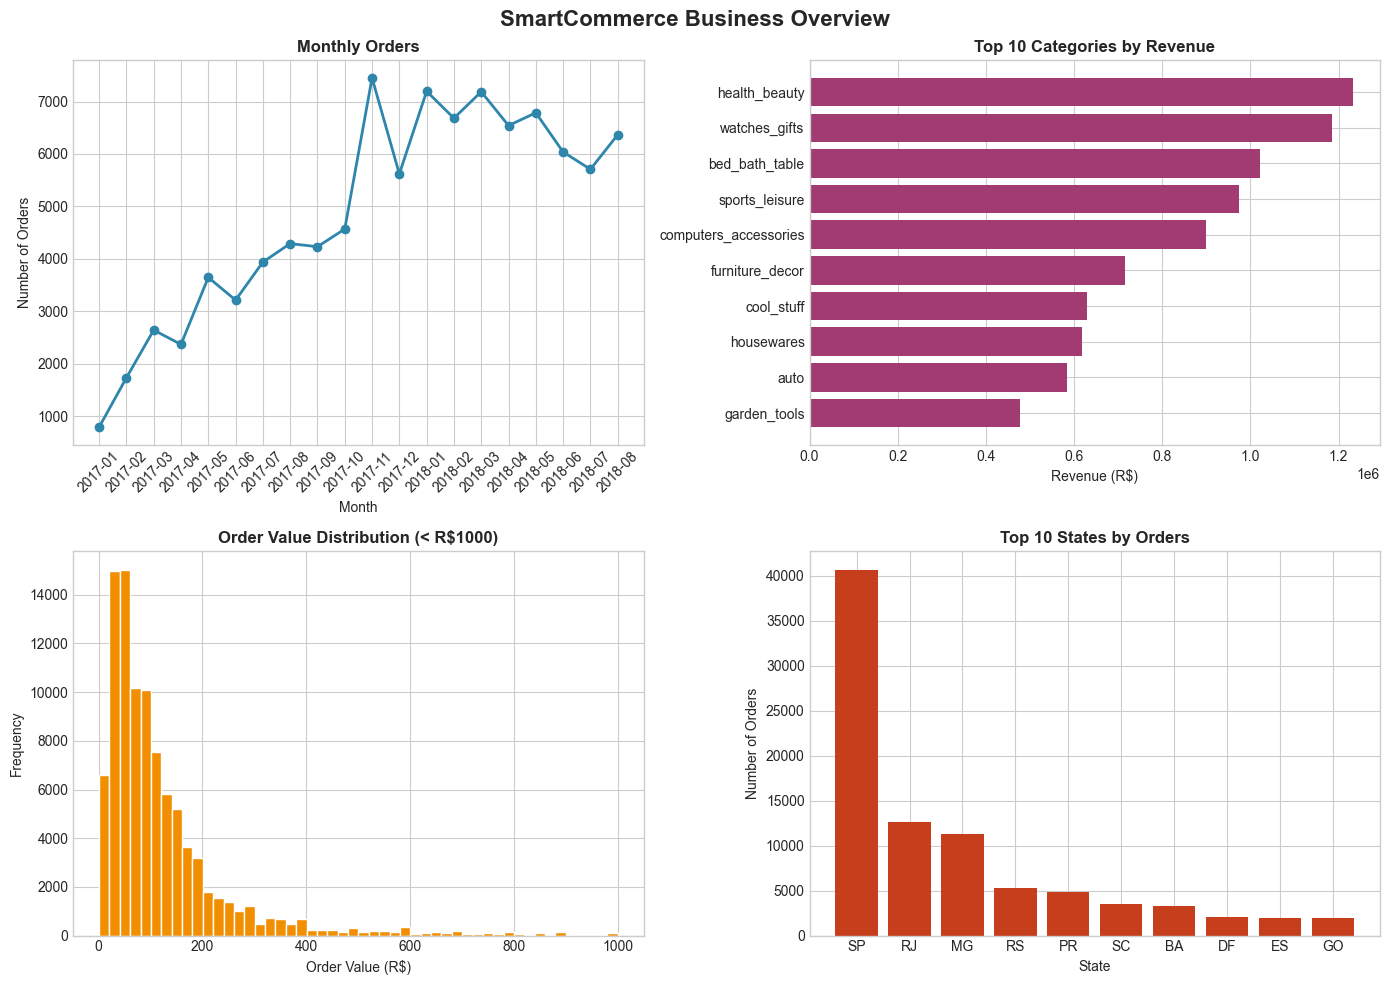

In [33]:
# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
fig_color = '#f8f9fa'

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SmartCommerce Business Overview', fontsize=16, fontweight='bold')

# 1. Orders over time
monthly_orders = df.groupby('year_month')['order_id'].nunique()
axes[0, 0].plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, color='#2E86AB')
axes[0, 0].set_title('Monthly Orders', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Orders')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Revenue by category (top 10)
cat_revenue = df.groupby('product_category_name_english')['price'].sum().nlargest(10)
axes[0, 1].barh(cat_revenue.index, cat_revenue.values, color='#A23B72')
axes[0, 1].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0, 1].set_xlabel('Revenue (R$)')
axes[0, 1].invert_yaxis()

# 3. Order value distribution
order_values = df.groupby('order_id')['price'].sum()
axes[1, 0].hist(order_values[order_values < 1000], bins=50, color='#F18F01', edgecolor='white')
axes[1, 0].set_title('Order Value Distribution (< R$1000)', fontweight='bold')
axes[1, 0].set_xlabel('Order Value (R$)')
axes[1, 0].set_ylabel('Frequency')

# 4. Orders by state (top 10)
state_orders = df.groupby('customer_state')['order_id'].nunique().nlargest(10)
axes[1, 1].bar(state_orders.index, state_orders.values, color='#C73E1D')
axes[1, 1].set_title('Top 10 States by Orders', fontweight='bold')
axes[1, 1].set_xlabel('State')
axes[1, 1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

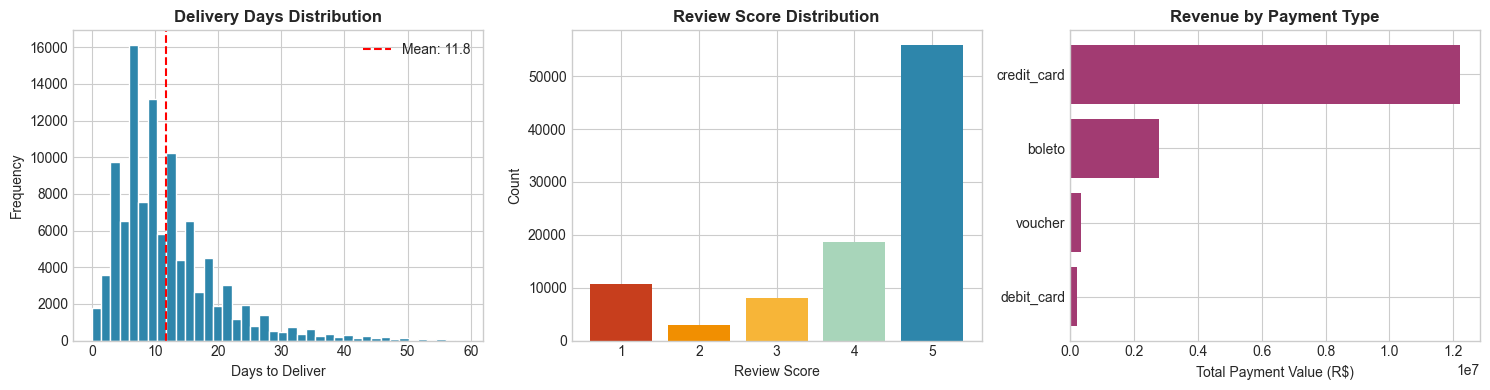

In [34]:
# Delivery and Review Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Delivery days distribution
delivered_data = df[df['delivery_days'].notna() & (df['delivery_days'] < 60)]
axes[0].hist(delivered_data['delivery_days'], bins=40, color='#2E86AB', edgecolor='white')
axes[0].axvline(delivered_data['delivery_days'].mean(), color='red', linestyle='--', label=f"Mean: {delivered_data['delivery_days'].mean():.1f}")
axes[0].set_title('Delivery Days Distribution', fontweight='bold')
axes[0].set_xlabel('Days to Deliver')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Review score distribution
score_counts = olist['reviews']['review_score'].value_counts().sort_index()
colors = ['#C73E1D', '#F18F01', '#F7B538', '#A8D5BA', '#2E86AB']
axes[1].bar(score_counts.index, score_counts.values, color=colors)
axes[1].set_title('Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Count')

# 3. Payment type distribution
payment_dist = olist['payments'].groupby('payment_type')['payment_value'].sum().sort_values(ascending=True)
axes[2].barh(payment_dist.index, payment_dist.values, color='#A23B72')
axes[2].set_title('Revenue by Payment Type', fontweight='bold')
axes[2].set_xlabel('Total Payment Value (R$)')

plt.tight_layout()
plt.show()

---

## 6. Save Prepared Dataset

Save the consolidated dataset for use in future labs.


In [36]:
# Save consolidated dataset for future labs
df.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Saved consolidated dataset to: {OUTPUT_FILE}")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Size: {os.path.getsize(OUTPUT_FILE) / 1e6:.2f} MB")

✅ Saved consolidated dataset to: C:\Users\iam_h\Jupyter\IT5006_Project-Data\data\business\smartcommerce_consolidated.csv
   Shape: 110,683 rows × 37 columns
   Size: 51.80 MB


---

## ✅ Lab Summary

### What you finished!

1. **Data Loading**: Loaded 9 interconnected Olist tables
2. **Schema Understanding**: Identified key columns and relationships
3. **Table Merging**: Built a consolidated analysis dataset using `merge()`
4. **KPI Computation**: Calculated core e-commerce metrics:
   - Revenue & AOV
   - Repeat Rate
   - Delivery Performance
   - Customer Satisfaction


---

## 📝 Exercise (Optional)

1. Calculate the **month-over-month growth rate** for orders
2. Find the **top 5 sellers by revenue**
3. Identify which **product category has the worst delivery performance**


In [38]:
df.describe()

,order_item_id,shipping_limit_date,price,freight_value,item_revenue,product_description_lenght,product_photos_qty,product_weight_g,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,delivery_days,payment_value_sum,payment_installments_max,review_score
count,110683.00,110683,110683.00,110683.00,110683.00,109093.00,109093.00,110665.00,110683,110668,109526,108286,110683,110683.00,110683.00,108286.00,110683.00,110683.00,109757.00
mean,1.20,2018-01-07 08:36:15.340467968,120.75,19.98,140.74,787.72,2.21,2098.96,2017-12-31 16:52:11.477047040,2018-01-01 03:48:44.468590592,2018-01-04 15:31:09.200308480,2018-01-14 02:55:30.877814272,2018-01-24 10:34:57.557890816,2017.54,6.02,12.05,180.38,3.02,4.03
min,1.00,2017-01-09 11:56:06,0.85,0.00,6.08,4.00,1.00,0.00,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,2017.00,1.00,0.00,9.59,0.00,1.00
25%,1.00,2017-09-20 21:50:15,39.90,13.08,55.22,348.00,1.00,300.00,2017-09-13 20:29:11,2017-09-14 09:19:50.750000128,2017-09-18 20:24:31.500000,2017-09-26 19:45:48.249999872,2017-10-05 00:00:00,2017.00,3.00,6.00,65.60,1.00,4.00
50%,1.00,2018-01-25 09:10:25,74.99,16.25,92.35,603.00,1.00,700.00,2018-01-18 10:53:08,2018-01-18 15:36:27.500000,2018-01-23 18:32:01,2018-02-01 12:58:32,2018-02-14 00:00:00,2018.00,6.00,10.00,114.44,2.00,5.00
75%,1.00,2018-05-09 22:55:12,134.90,21.15,157.97,986.00,3.00,1800.00,2018-05-03 12:43:11,2018-05-03 18:15:25,2018-05-07 14:04:00,2018-05-14 20:10:22.750000128,2018-05-25 00:00:00,2018.00,8.00,15.00,195.12,4.00,5.00
max,21.00,2020-04-09 22:35:08,6735.00,409.68,6929.31,3992.00,20.00,40425.00,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,2018.00,12.00,209.00,13664.08,24.00,5.00
std,0.71,NaN,184.00,15.82,191.09,652.40,1.72,3761.90,NaN,NaN,NaN,NaN,NaN,0.50,3.25,9.46,273.97,2.80,1.39


In [39]:
# -------------------------------------------------------------
# Reusable Plotting Function
# -------------------------------------------------------------
def plot_trend_with_highlights(
    ax, data_df, series_cols, title, ylabel, 
    threshold=0.0, mode='pct_change', continuous_months=3, is_increase_bad=False
):
    """
    Plots trend lines and highlights continuous threshold breaches with red scatter points.
    
    Parameters:
        mode: 'pct_change' (vs 3-mo MA) or 'absolute_below' (fixed value threshold)
        is_increase_bad: True if an increase exceeds threshold, False if a drop triggers it.
    """
    for col in series_cols:
        s = data_df[col]
        
        # Determine condition triggers
        if mode == 'pct_change':
            ma = s.shift(1).rolling(window=3).mean()
            metric = (s - ma) / ma
            is_triggered = (metric > threshold) if is_increase_bad else (metric < -threshold)
        elif mode == 'absolute_below':
            is_triggered = (s < threshold)
            
        # Count continuous streaks
        streak = is_triggered.groupby((~is_triggered).cumsum()).cumsum()
        highlight = streak >= continuous_months
        
        # Plot time series & highlight points
        ax.plot(data_df.index, s, label=col, linewidth=2)
        if highlight.any():
            ax.scatter(data_df.index[highlight], s[highlight], color='red', s=80, zorder=5)
            
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='best', fontsize=8)


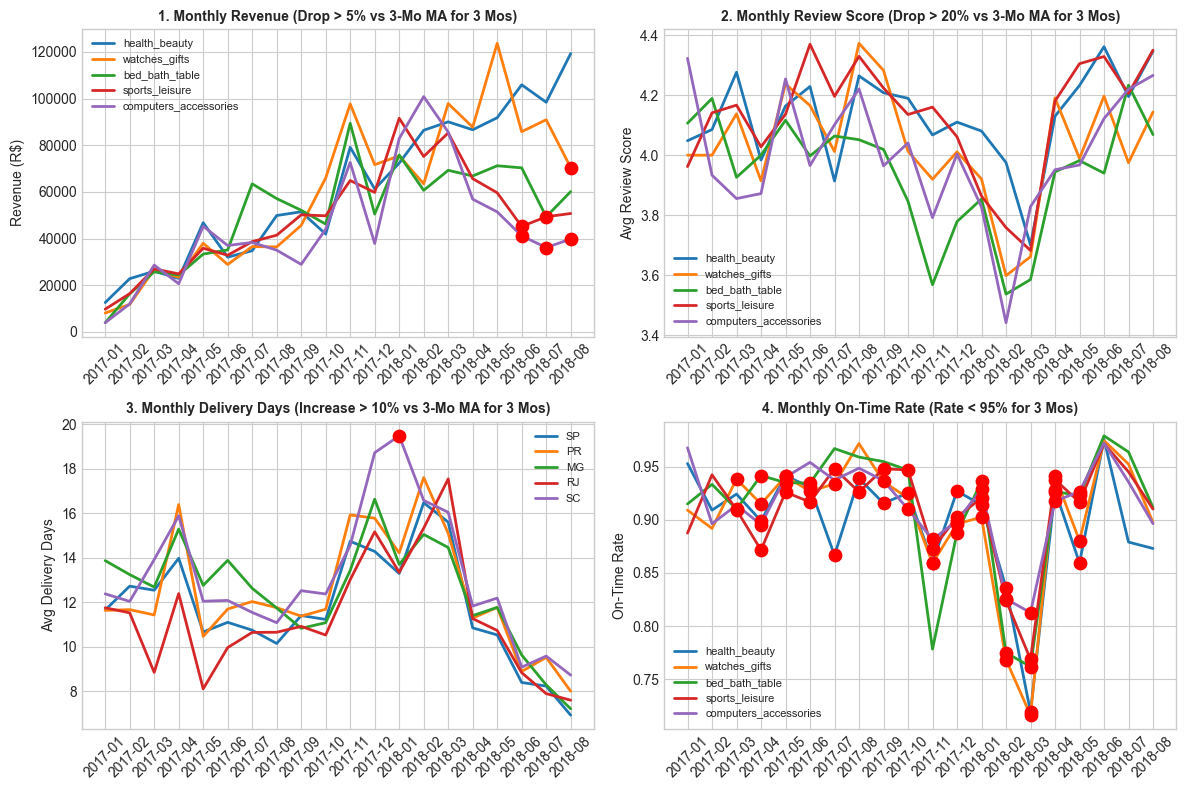

In [40]:
# -------------------------------------------------------------
# Data Preparation
# -------------------------------------------------------------
revenue_threshold = 0.05    # 5%
review_threshold = 0.20     # 20%
delivery_threshold = 0.10   # 10%
on_time_threshold = 0.95    # 95%

# Top 5 Categories & States Dataframes
top_5_cats = df.groupby('product_category_name_english')['price'].sum().nlargest(5).index.tolist()
df_top = df[df['product_category_name_english'].isin(top_5_cats)]
top_states = df.groupby('seller_state')['price'].sum().nlargest(5).index.tolist()

# Aggregated Pivot Tables
rev_monthly = df_top.groupby(['year_month', 'product_category_name_english'])['price'].sum().unstack()
review_monthly = df_top.groupby(['year_month', 'product_category_name_english'])['review_score'].mean().unstack()
deliv_monthly = df.groupby(['year_month', 'seller_state'])['delivery_days'].mean().unstack()[top_states]
ontime_monthly = df_top.groupby(['year_month', 'product_category_name_english'])['is_on_time'].mean().unstack()

# -------------------------------------------------------------
# 2x2 Dashboard Rendering
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Revenue
plot_trend_with_highlights(
    axes[0, 0], rev_monthly, top_5_cats,
    title="1. Monthly Revenue (Drop > 5% vs 3-Mo MA for 3 Mos)",
    ylabel="Revenue (R$)", threshold=revenue_threshold, mode='pct_change'
)

# 2. Review Score
plot_trend_with_highlights(
    axes[0, 1], review_monthly, top_5_cats,
    title="2. Monthly Review Score (Drop > 20% vs 3-Mo MA for 3 Mos)",
    ylabel="Avg Review Score", threshold=review_threshold, mode='pct_change'
)

# 3. Delivery Days
plot_trend_with_highlights(
    axes[1, 0], deliv_monthly, top_states,
    title="3. Monthly Delivery Days (Increase > 10% vs 3-Mo MA for 3 Mos)",
    ylabel="Avg Delivery Days", threshold=delivery_threshold, mode='pct_change', is_increase_bad=True
)

# 4. On-Time Delivery Rate
plot_trend_with_highlights(
    axes[1, 1], ontime_monthly, top_5_cats,
    title="4. Monthly On-Time Rate (Rate < 95% for 3 Mos)",
    ylabel="On-Time Rate", threshold=on_time_threshold, mode='absolute_below'
)

plt.tight_layout()
plt.show()

In [41]:
# Count distinct review_ids for each order_id
review_counts = reviews.groupby('order_id')['review_id'].nunique()

# Filter for order_ids that have more than 1 review_id
multiple_reviews = review_counts[review_counts > 1]

print(f"Orders with multiple reviews: {len(multiple_reviews)}")
print(multiple_reviews)

Orders with multiple reviews: 0
Series([], Name: review_id, dtype: int64)
